# Muhammad Huzaifa
# AI, ML, DL
# Batch 1

### Importing All Necessary libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sklearn as sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Analyzing The Data sets

In [2]:
fd_Data = pd.read_csv("./FraudData.csv")
print(fd_Data.head())
print(fd_Data.info())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 # 

In [4]:
fin_df = pd.read_csv("./yFinData.csv")
print(fin_df.head())
print(fin_df.info())

        Date      Open      High       Low     Close  Adj Close     Volume
0  4/28/2023  33797.43  34104.56  33728.40  34098.16   34098.16  354310000
1  4/29/2023  33381.66  33859.75  33374.65  33826.16   33826.16  343240000
2  4/30/2023  33596.34  33645.83  33235.85  33301.87   33301.87  321170000
3   5/1/2023  33828.34  33875.49  33525.39  33530.83   33530.83  297880000
4   5/2/2023  33805.04  33891.15  33726.09  33875.40   33875.40  252020000
<class 'pandas.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1258 non-null   str    
 1   Open       1258 non-null   float64
 2   High       1258 non-null   float64
 3   Low        1258 non-null   float64
 4   Close      1258 non-null   float64
 5   Adj Close  1258 non-null   float64
 6   Volume     1258 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 68.9 KB
None


In [5]:
st_df = pd.read_csv("./StPerformData.csv")
print(st_df.head())
print(st_df.info())

   student_id  age  gender school_type parent_education  study_hours  \
0           1   14    male      public    post graduate          3.1   
1           2   18  female      public         graduate          3.7   
2           3   17  female     private    post graduate          7.9   
3           4   16   other      public      high school          1.1   
4           5   16  female      public      high school          1.3   

   attendance_percentage internet_access travel_time extra_activities  \
0                   84.3             yes     <15 min              yes   
1                   87.8             yes     >60 min               no   
2                   65.5              no     <15 min               no   
3                   58.1              no   15-30 min               no   
4                   61.0             yes   30-60 min              yes   

  study_method  math_score  science_score  english_score  overall_score  \
0        notes        42.7           55.4           5

### Section A (Data Cleaning & Preprocessing)

#### Question 4: Perform Cleaning & Preprocessng on Sales Dataset

In [6]:
# ============================================================================
# STEP 1: LOAD AND EXPLORE THE DATASET
# ============================================================================
# Load the sales dataset (using FraudData.csv for this exercise)
sales_df = pd.read_csv("./FraudData.csv")

# Display basic information about the dataset
print("=" * 70)
print("STEP 1: DATASET OVERVIEW")
print("=" * 70)
print(f"\nShape: {sales_df.shape[0]} rows × {sales_df.shape[1]} columns")
print(f"\nColumn Names and Data Types:")
print(sales_df.dtypes)
print(f"\nFirst 5 rows:")
print(sales_df.head())
print(f"\nBasic Statistics:")
print(sales_df.describe())

# Check for missing values
print("\n" + "=" * 70)
print("Missing Values Check:")
print("=" * 70)
missing_values = sales_df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")

# Check for duplicate rows
print(f"\nDuplicate Rows: {sales_df.duplicated().sum()}")
print(f"\nDataset Info:")
sales_df.info()

STEP 1: DATASET OVERVIEW

Shape: 6362620 rows × 11 columns

Column Names and Data Types:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

First 5 rows:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0

In [7]:
# ============================================================================
# STEP 2: HANDLE MISSING VALUES
# ============================================================================
# Check for missing values in detail
print("\n" + "=" * 70)
print("STEP 2: HANDLING MISSING VALUES")
print("=" * 70)

missing_percent = (sales_df.isnull().sum() / len(sales_df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': sales_df.isnull().sum(),
    'Missing Percentage': missing_percent
})
print("\nMissing Values Summary:")
print(missing_df[missing_df['Missing Count'] > 0])

# Handle missing values - Fill numerical columns with mean, categorical with mode
print("\nFilling missing values...")
for col in sales_df.columns:
    if sales_df[col].isnull().sum() > 0:
        if sales_df[col].dtype in ['float64', 'int64']:
            # Fill numerical columns with median (more robust than mean for outliers)
            sales_df[col].fillna(sales_df[col].median(), inplace=True)
            print(f"  - {col}: filled with median")
        else:
            # Fill categorical columns with mode
            sales_df[col].fillna(sales_df[col].mode()[0], inplace=True)
            print(f"  - {col}: filled with mode")

print(f"\nMissing values after cleaning: {sales_df.isnull().sum().sum()}")


STEP 2: HANDLING MISSING VALUES

Missing Values Summary:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []

Filling missing values...

Missing values after cleaning: 0


In [8]:
# ============================================================================
# STEP 3: REMOVE DUPLICATES
# ============================================================================
print("\n" + "=" * 70)
print("STEP 3: REMOVING DUPLICATES")
print("=" * 70)

duplicates_before = sales_df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates_before}")

if duplicates_before > 0:
    # Remove completely duplicate rows (all columns same)
    sales_df.drop_duplicates(inplace=True)
    duplicates_after = sales_df.duplicated().sum()
    print(f"Duplicate rows after removal: {duplicates_after}")
    print(f"Shape after removing duplicates: {sales_df.shape}")
else:
    print("No duplicate rows found - dataset is clean!")

print(f"Dataset shape: {sales_df.shape[0]} rows × {sales_df.shape[1]} columns")


STEP 3: REMOVING DUPLICATES

Duplicate rows found: 0
No duplicate rows found - dataset is clean!
Dataset shape: 6362620 rows × 11 columns


In [9]:
# ============================================================================
# STEP 4: DETECT AND HANDLE OUTLIERS (IQR Method)
# ============================================================================
print("\n" + "=" * 70)
print("STEP 4: DETECTING AND HANDLING OUTLIERS")
print("=" * 70)

# Select only numerical columns for outlier detection
numerical_cols = sales_df.select_dtypes(include=['float64', 'int64']).columns

print("\nOutlier Detection using IQR (Interquartile Range) method:")
print("-" * 70)

outlier_summary = {}
for col in numerical_cols:
    Q1 = sales_df[col].quantile(0.25)
    Q3 = sales_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outliers = ((sales_df[col] < lower_bound) | (sales_df[col] > upper_bound)).sum()
    
    if outliers > 0:
        outlier_summary[col] = outliers
        print(f"\n{col}:")
        print(f"  - Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
        print(f"  - Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
        print(f"  - Outliers found: {outliers}")
        
        # Cap outliers (replace with bounds instead of removing)
        sales_df[col] = sales_df[col].clip(lower_bound, upper_bound)
        print(f"  - Action: Capped outliers to bounds")

if not outlier_summary:
    print("\nNo significant outliers detected using IQR method.")


STEP 4: DETECTING AND HANDLING OUTLIERS

Outlier Detection using IQR (Interquartile Range) method:
----------------------------------------------------------------------

step:
  - Q1: 156.00, Q3: 335.00, IQR: 179.00
  - Lower bound: -112.50, Upper bound: 603.50
  - Outliers found: 102688
  - Action: Capped outliers to bounds

amount:
  - Q1: 13389.57, Q3: 208721.48, IQR: 195331.91
  - Lower bound: -279608.29, Upper bound: 501719.34
  - Outliers found: 338078
  - Action: Capped outliers to bounds

oldbalanceOrg:
  - Q1: 0.00, Q3: 107315.18, IQR: 107315.18
  - Lower bound: -160972.76, Upper bound: 268287.94
  - Outliers found: 1112507
  - Action: Capped outliers to bounds

newbalanceOrig:
  - Q1: 0.00, Q3: 144258.41, IQR: 144258.41
  - Lower bound: -216387.61, Upper bound: 360646.03
  - Outliers found: 1053391
  - Action: Capped outliers to bounds

oldbalanceDest:
  - Q1: 0.00, Q3: 943036.71, IQR: 943036.71
  - Lower bound: -1414555.06, Upper bound: 2357591.77
  - Outliers found: 78613

In [10]:
# ============================================================================
# STEP 5: DATA TYPE OPTIMIZATION
# ============================================================================
print("\n" + "=" * 70)
print("STEP 5: DATA TYPE OPTIMIZATION")
print("=" * 70)

print("\nOriginal Data Types:")
print(sales_df.dtypes)

# Identify categorical columns (object type)
categorical_cols = sales_df.select_dtypes(include=['object']).columns

print(f"\nCategorical columns found: {list(categorical_cols)}")
print("\nUnique value counts per categorical column:")
for col in categorical_cols:
    print(f"  - {col}: {sales_df[col].nunique()} unique values")

# Convert object to category for memory efficiency
print("\nConverting categorical columns to 'category' type...")
for col in categorical_cols:
    sales_df[col] = sales_df[col].astype('category')
    print(f"  - {col}: converted to category type")

print("\nUpdated Data Types:")
print(sales_df.dtypes)


STEP 5: DATA TYPE OPTIMIZATION

Original Data Types:
step              float64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Categorical columns found: ['type', 'nameOrig', 'nameDest']

Unique value counts per categorical column:


C:\Users\cfl602\AppData\Local\Temp\ipykernel_6296\3446256098.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = sales_df.select_dtypes(include=['object']).columns


  - type: 5 unique values
  - nameOrig: 6353307 unique values
  - nameDest: 2722362 unique values

Converting categorical columns to 'category' type...
  - type: converted to category type
  - nameOrig: converted to category type
  - nameDest: converted to category type

Updated Data Types:
step               float64
type              category
amount             float64
nameOrig          category
oldbalanceOrg      float64
newbalanceOrig     float64
nameDest          category
oldbalanceDest     float64
newbalanceDest     float64
isFraud              int64
isFlaggedFraud       int64
dtype: object


In [11]:
# ============================================================================
# STEP 6: ENCODE CATEGORICAL VARIABLES
# ============================================================================
print("\n" + "=" * 70)
print("STEP 6: ENCODING CATEGORICAL VARIABLES")
print("=" * 70)

# Create a copy for encoding (preserve original for comparison)
sales_df_encoded = sales_df.copy()

# Convert categorical back to object for encoding
for col in categorical_cols:
    sales_df_encoded[col] = sales_df_encoded[col].astype('object')

print("\nUsing Label Encoding for categorical variables...")
print("-" * 70)

# Apply Label Encoding to categorical columns
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    sales_df_encoded[col] = le.fit_transform(sales_df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"\n{col}:")
    print(f"  - Original unique values: {list(le.classes_[:5])}{'...' if len(le.classes_) > 5 else ''}")
    print(f"  - Encoded mapping (sample): {dict(zip(le.classes_[:3], le.transform(le.classes_[:3])))}")

print("\nData after encoding:")
print(sales_df_encoded.head())


STEP 6: ENCODING CATEGORICAL VARIABLES

Using Label Encoding for categorical variables...
----------------------------------------------------------------------

type:
  - Original unique values: ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
  - Encoded mapping (sample): {'CASH_IN': np.int64(0), 'CASH_OUT': np.int64(1), 'DEBIT': np.int64(2)}

nameOrig:
  - Original unique values: ['C1000000639', 'C1000001337', 'C1000001725', 'C1000002591', 'C1000003372']...
  - Encoded mapping (sample): {'C1000000639': np.int64(0), 'C1000001337': np.int64(1), 'C1000001725': np.int64(2)}

nameDest:
  - Original unique values: ['C1000004082', 'C1000004940', 'C1000013769', 'C100001587', 'C1000015936']...
  - Encoded mapping (sample): {'C1000004082': np.int64(0), 'C1000004940': np.int64(1), 'C1000013769': np.int64(2)}

Data after encoding:
   step  type    amount  nameOrig  oldbalanceOrg  newbalanceOrig  nameDest  \
0   1.0     3   9839.64    757869       170136.0       160296.36   1662094   
1 

In [12]:
# ============================================================================
# STEP 7: FEATURE SCALING (NORMALIZATION)
# ============================================================================
print("\n" + "=" * 70)
print("STEP 7: FEATURE SCALING/NORMALIZATION")
print("=" * 70)

# Get numerical columns for scaling
numerical_cols_for_scaling = sales_df_encoded.select_dtypes(include=['float64', 'int64']).columns

print(f"\nNumerical columns to scale: {list(numerical_cols_for_scaling)}")

# Create a copy for scaled data
sales_df_scaled = sales_df_encoded.copy()

# Apply Min-Max Scaling (0-1 normalization)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
sales_df_scaled[numerical_cols_for_scaling] = scaler.fit_transform(sales_df_encoded[numerical_cols_for_scaling])

print("\nMin-Max Scaling applied (range: 0-1)")
print("\nStatistics before scaling:")
print(sales_df_encoded[numerical_cols_for_scaling].describe().loc[['min', 'max']])

print("\nStatistics after scaling:")
print(sales_df_scaled[numerical_cols_for_scaling].describe().loc[['min', 'max']])

print("\nSample data after all preprocessing steps:")
print(sales_df_scaled.head(10))


STEP 7: FEATURE SCALING/NORMALIZATION

Numerical columns to scale: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Min-Max Scaling applied (range: 0-1)

Statistics before scaling:
      step  type        amount   nameOrig  oldbalanceOrg  newbalanceOrig  \
min    1.0   0.0       0.00000        0.0         0.0000           0.000   
max  603.5   4.0  501719.33875  6353306.0    268287.9375      360646.025   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
min        0.0    0.000000e+00           0.000      0.0             0.0  
max  2722361.0    2.357592e+06     2779773.125      0.0             0.0  

Statistics after scaling:
     step  type  amount  nameOrig  oldbalanceOrg  newbalanceOrig  nameDest  \
min   0.0   0.0     0.0       0.0            0.0             0.0       0.0   
max   1.0   1.0     1.0       1.0            1.0             1.0       1.0   

  

In [13]:
# ============================================================================
# STEP 8: PREPROCESSING SUMMARY & COMPARISON
# ============================================================================
print("\n" + "=" * 70)
print("STEP 8: PREPROCESSING SUMMARY")
print("=" * 70)

print("\n📊 BEFORE & AFTER COMPARISON:")
print("-" * 70)
print(f"Original Dataset Shape:     {sales_df.shape}")
print(f"Processed Dataset Shape:    {sales_df_scaled.shape}")
print(f"Total rows removed:         {sales_df.shape[0] - sales_df_scaled.shape[0]}")

print("\n✅ CLEANING OPERATIONS PERFORMED:")
print("-" * 70)
print("1. ✓ Loaded and explored dataset")
print("2. ✓ Handled missing values (filled with median/mode)")
print("3. ✓ Removed duplicate rows")
print("4. ✓ Detected and capped outliers (IQR method)")
print("5. ✓ Optimized data types (category conversion)")
print("6. ✓ Encoded categorical variables (Label Encoding)")
print("7. ✓ Scaled numerical features (Min-Max normalization)")

print("\n📋 DATA QUALITY METRICS:")
print("-" * 70)
print(f"Total Missing Values (after):    {sales_df_scaled.isnull().sum().sum()}")
print(f"Total Duplicate Rows (after):    {sales_df_scaled.duplicated().sum()}")
print(f"Total Columns:                   {sales_df_scaled.shape[1]}")
print(f"Total Rows:                      {sales_df_scaled.shape[0]}")

print("\n🔍 FINAL DATASET INFO:")
print("-" * 70)
print(sales_df_scaled.info())

print("\n✨ PREPROCESSING COMPLETE! ✨")
print("The dataset is now clean, normalized, and ready for machine learning models.")


STEP 8: PREPROCESSING SUMMARY

📊 BEFORE & AFTER COMPARISON:
----------------------------------------------------------------------
Original Dataset Shape:     (6362620, 11)
Processed Dataset Shape:    (6362620, 11)
Total rows removed:         0

✅ CLEANING OPERATIONS PERFORMED:
----------------------------------------------------------------------
1. ✓ Loaded and explored dataset
2. ✓ Handled missing values (filled with median/mode)
3. ✓ Removed duplicate rows
4. ✓ Detected and capped outliers (IQR method)
5. ✓ Optimized data types (category conversion)
6. ✓ Encoded categorical variables (Label Encoding)
7. ✓ Scaled numerical features (Min-Max normalization)

📋 DATA QUALITY METRICS:
----------------------------------------------------------------------
Total Missing Values (after):    0
Total Duplicate Rows (after):    0
Total Columns:                   11
Total Rows:                      6362620

🔍 FINAL DATASET INFO:
------------------------------------------------------------------

### Question 6: Preprocess and Clean Financial Dataset

In [17]:
# ============================================================================
# QUESTION 6: PREPROCESS AND CLEAN FINANCIAL DATASET (yFinData.csv)
# ============================================================================
print("=" * 80)
print("QUESTION 6: FINANCIAL DATA PREPROCESSING")
print("=" * 80)

# Load financial data
financial_df = pd.read_csv("./yFinData.csv")

print("\n1. INITIAL DATA EXPLORATION")
print("-" * 80)
print(f"Shape: {financial_df.shape}")
print(f"\nData Types:\n{financial_df.dtypes}")
print(f"\nFirst 5 rows:\n{financial_df.head()}")

# Convert Date column to datetime
financial_df['Date'] = pd.to_datetime(financial_df['Date'])
financial_df = financial_df.sort_values('Date').reset_index(drop=True)

print("\n2. DATA CLEANING")
print("-" * 80)
print(f"Missing values:\n{financial_df.isnull().sum()}")
print(f"Duplicate rows: {financial_df.duplicated().sum()}")

# Remove duplicates if any
financial_df.drop_duplicates(inplace=True)

# Forward fill for any missing values (using newer pandas syntax)
financial_df = financial_df.ffill().bfill()

print("\n3. FEATURE ENGINEERING - CREATING TECHNICAL INDICATORS")
print("-" * 80)

# Calculate daily returns
financial_df['Daily_Return'] = financial_df['Close'].pct_change() * 100

# Calculate Moving Averages
financial_df['MA_5'] = financial_df['Close'].rolling(window=5).mean()
financial_df['MA_20'] = financial_df['Close'].rolling(window=20).mean()

# Calculate Volatility
financial_df['Volatility'] = financial_df['Daily_Return'].rolling(window=20).std()

# Calculate Price Range
financial_df['Price_Range'] = financial_df['High'] - financial_df['Low']

# Remove NaN values created by rolling calculations
financial_df = financial_df.dropna()

print(f"New columns created: Daily_Return, MA_5, MA_20, Volatility, Price_Range")
print(f"\nCleaned Financial Data Shape: {financial_df.shape}")
print(f"\nProcessed Data Sample:\n{financial_df.head(10)}")
print(f"\nData Summary:\n{financial_df.describe()}")

# Store for later use
financial_df_clean = financial_df.copy()

QUESTION 6: FINANCIAL DATA PREPROCESSING

1. INITIAL DATA EXPLORATION
--------------------------------------------------------------------------------
Shape: (1258, 7)

Data Types:
Date             str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

First 5 rows:
        Date      Open      High       Low     Close  Adj Close     Volume
0  4/28/2023  33797.43  34104.56  33728.40  34098.16   34098.16  354310000
1  4/29/2023  33381.66  33859.75  33374.65  33826.16   33826.16  343240000
2  4/30/2023  33596.34  33645.83  33235.85  33301.87   33301.87  321170000
3   5/1/2023  33828.34  33875.49  33525.39  33530.83   33530.83  297880000
4   5/2/2023  33805.04  33891.15  33726.09  33875.40   33875.40  252020000

2. DATA CLEANING
--------------------------------------------------------------------------------
Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj

## SECTION B: DATA VISUALIZATION & EXPLORATORY DATA ANALYSIS
### Question 8 & 9: Data Visualizations using Matplotlib and Seaborn

In [22]:
# ============================================================================
# QUESTIONS 8 & 9: DATA VISUALIZATIONS - PART 1: DATA SETUP
# ============================================================================
print("\n" + "=" * 80)
print("QUESTIONS 8 & 9: EXPLORATORY DATA ANALYSIS WITH VISUALIZATIONS")
print("=" * 80)

# Use student performance data
student_df = st_df.copy()

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

# Create grade categories mapping
grade_mapping = {'a': 'Excellent', 'b': 'Good', 'c': 'Average', 'd': 'Below Avg', 'e': 'Poor', 'f': 'Fail'}
student_df['grade_category'] = student_df['final_grade'].map(grade_mapping)

print(f"Student data loaded: {student_df.shape[0]} records")
print(f"Columns: {student_df.columns.tolist()}")


QUESTIONS 8 & 9: EXPLORATORY DATA ANALYSIS WITH VISUALIZATIONS
Student data loaded: 25000 records
Columns: ['student_id', 'age', 'gender', 'school_type', 'parent_education', 'study_hours', 'attendance_percentage', 'internet_access', 'travel_time', 'extra_activities', 'study_method', 'math_score', 'science_score', 'english_score', 'overall_score', 'final_grade', 'grade_category']


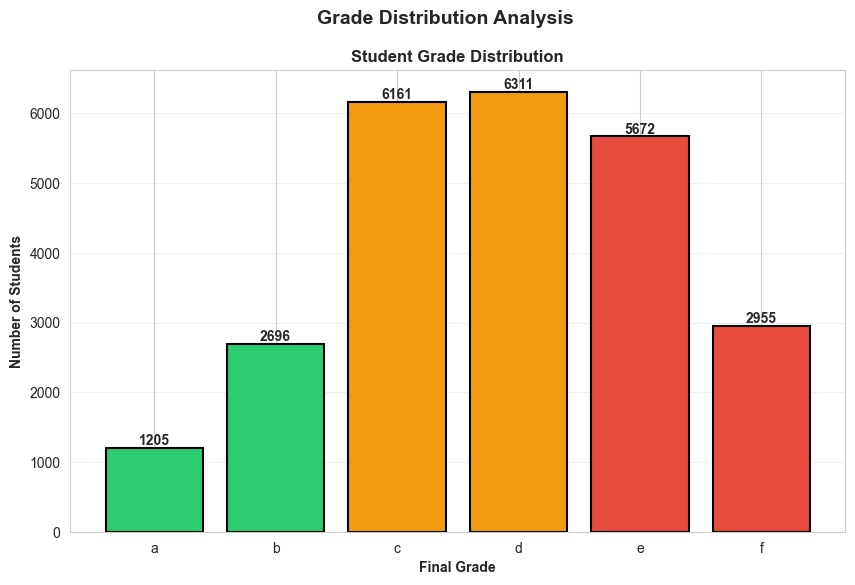

In [42]:
# Chart 1: Bar Chart - Grade Distribution
fig, ax1 = plt.subplots(figsize=(10, 6))
fig.suptitle('Grade Distribution Analysis', fontsize=14, fontweight='bold')

# Bar chart
grade_counts = student_df['final_grade'].value_counts().sort_index()
colors_bar = ['#2ecc71' if g in ['a', 'b'] else '#f39c12' if g in ['c', 'd'] else '#e74c3c' for g in grade_counts.index]
bars = ax1.bar(grade_counts.index, grade_counts.values, color=colors_bar, edgecolor='black', linewidth=1.5)
ax1.set_title('Student Grade Distribution', fontweight='bold', fontsize=12)
ax1.set_xlabel('Final Grade', fontweight='bold')
ax1.set_ylabel('Number of Students', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

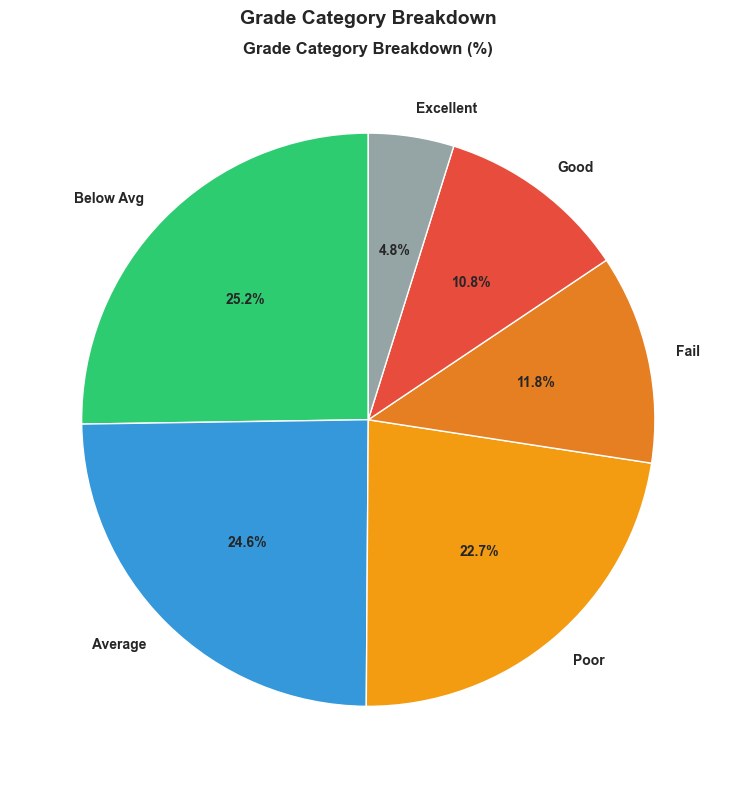

✓ Grade distribution charts created


In [43]:
# Chart 2: Pie Chart - Grade Categories
fig2, ax2 = plt.subplots(figsize=(8, 8))
fig2.suptitle('Grade Category Breakdown', fontsize=14, fontweight='bold')

grade_dist = student_df['grade_category'].value_counts()
colors_pie = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c', '#95a5a6']
ax2.pie(grade_dist.values, labels=grade_dist.index, autopct='%1.1f%%',
        colors=colors_pie, startangle=90, textprops={'fontweight': 'bold'})
ax2.set_title('Grade Category Breakdown (%)', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Grade distribution charts created")

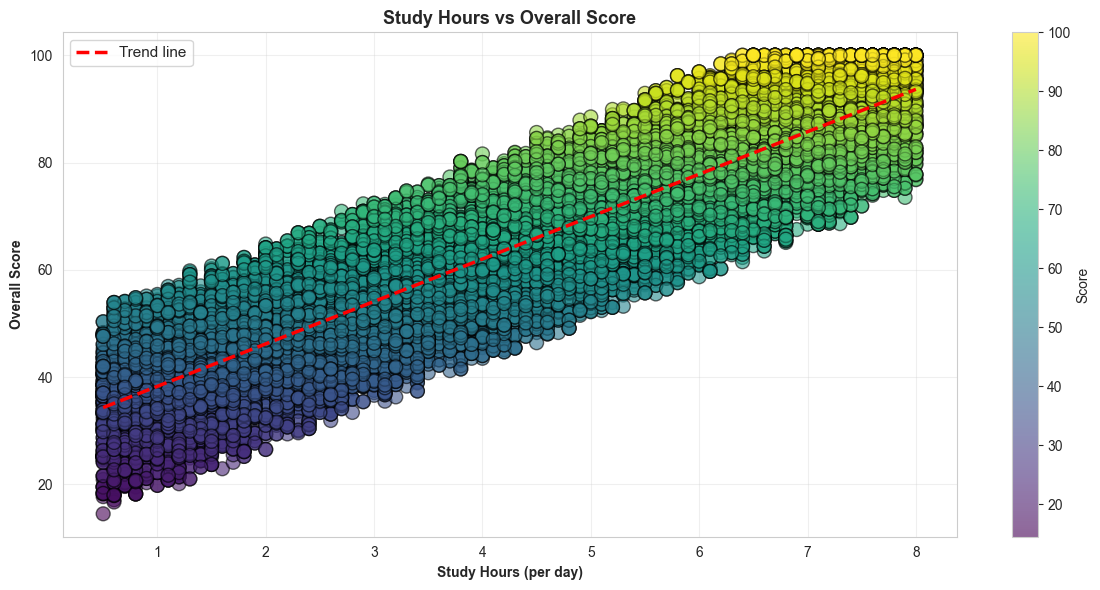

✓ Study hours correlation chart created


In [24]:
# Chart 2: Scatter Plot - Study Hours vs Overall Score
fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(student_df['study_hours'], student_df['overall_score'], 
                     c=student_df['overall_score'], cmap='viridis', s=100, alpha=0.6, edgecolors='black')
ax.set_title('Study Hours vs Overall Score', fontweight='bold', fontsize=13)
ax.set_xlabel('Study Hours (per day)', fontweight='bold')
ax.set_ylabel('Overall Score', fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Score')

# Add trend line
z = np.polyfit(student_df['study_hours'], student_df['overall_score'], 1)
p = np.poly1d(z)
ax.plot(student_df['study_hours'].sort_values(), p(student_df['study_hours'].sort_values()), 
         "r--", linewidth=2.5, label='Trend line')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Study hours correlation chart created")

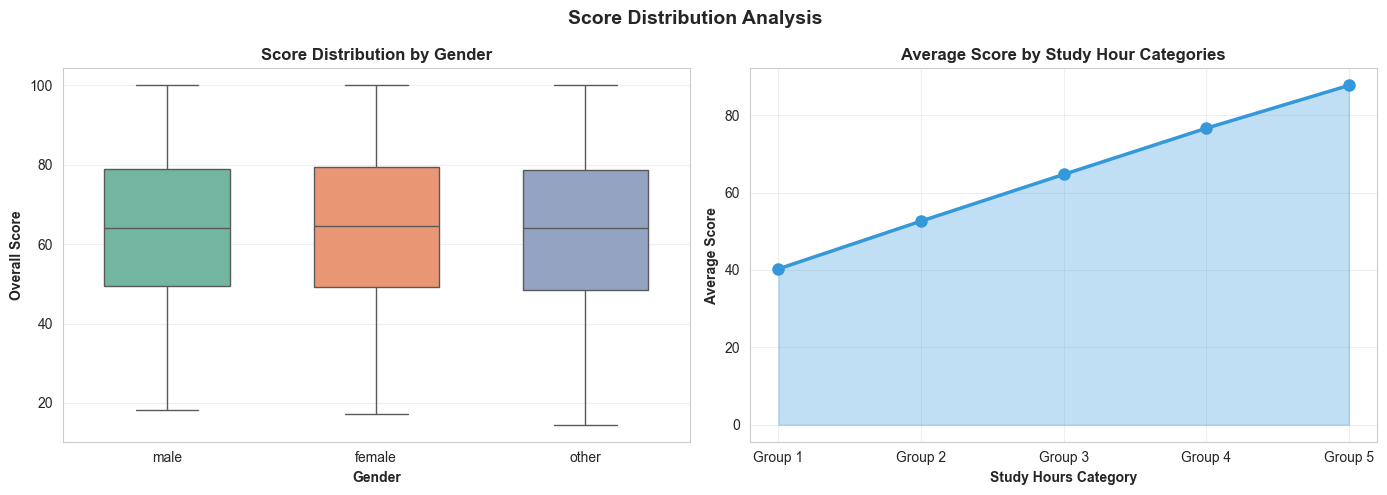

✓ Distribution and trend charts created


In [25]:
# Chart 3: Box Plot and Line Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Score Distribution Analysis', fontsize=14, fontweight='bold')

# Box plot
sns.boxplot(x='gender', y='overall_score', data=student_df, ax=ax1, palette='Set2', width=0.6)
ax1.set_title('Score Distribution by Gender', fontweight='bold')
ax1.set_xlabel('Gender', fontweight='bold')
ax1.set_ylabel('Overall Score', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Line chart - Average scores by study hours
study_bins = pd.cut(student_df['study_hours'], bins=5)
avg_scores = student_df.groupby(study_bins)['overall_score'].mean()
ax2.plot(range(len(avg_scores)), avg_scores.values, marker='o', linewidth=2.5, markersize=8, color='#3498db')
ax2.fill_between(range(len(avg_scores)), avg_scores.values, alpha=0.3, color='#3498db')
ax2.set_title('Average Score by Study Hour Categories', fontweight='bold')
ax2.set_xlabel('Study Hours Category', fontweight='bold')
ax2.set_ylabel('Average Score', fontweight='bold')
ax2.set_xticks(range(len(avg_scores)))
ax2.set_xticklabels([f'Group {i+1}' for i in range(len(avg_scores))], rotation=0)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Distribution and trend charts created")

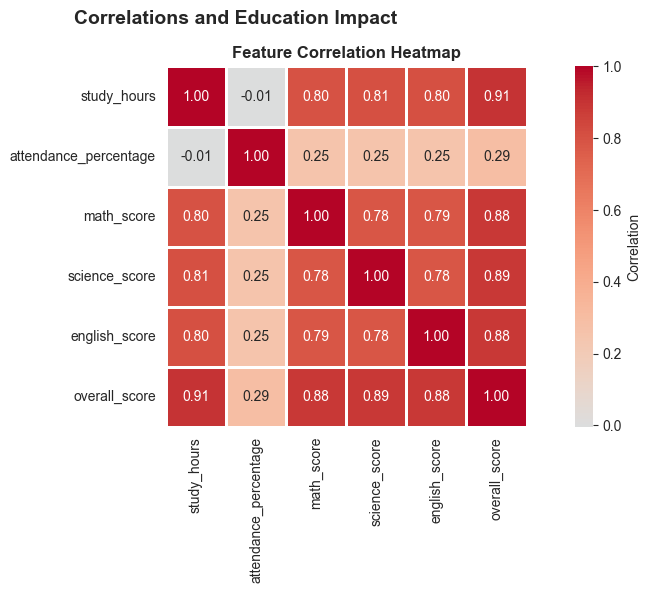

✓ Correlation chart created


In [46]:
# Chart 4: Heatmap
fig, ax1 = plt.subplots(figsize=(10, 6))
fig.suptitle('Correlations and Education Impact', fontsize=14, fontweight='bold')

# Heatmap
numeric_cols = student_df[['study_hours', 'attendance_percentage', 'math_score', 'science_score', 'english_score', 'overall_score']]
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax1, 
            cbar_kws={'label': 'Correlation'}, square=True, linewidths=1)
ax1.set_title('Feature Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Correlation chart created")

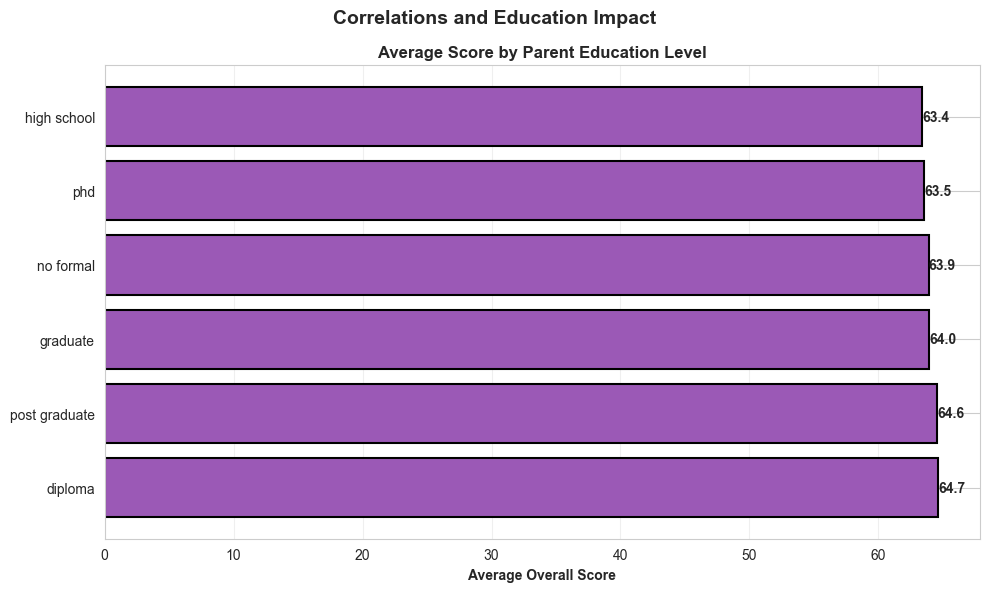

✓ Education impact chart created


In [47]:
# Chart 4: Bar Chart - Parent Education Impact
fig2, ax2 = plt.subplots(figsize=(10, 6))
fig2.suptitle('Correlations and Education Impact', fontsize=14, fontweight='bold')

# Bar chart - Parent education impact
parent_ed_scores = student_df.groupby('parent_education')['overall_score'].mean().sort_values(ascending=False)
bars = ax2.barh(parent_ed_scores.index, parent_ed_scores.values, color='#9b59b6', edgecolor='black', linewidth=1.5)
ax2.set_title('Average Score by Parent Education Level', fontweight='bold')
ax2.set_xlabel('Average Overall Score', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for bar in bars:
    ax2.text(bar.get_width(), bar.get_y() + bar.get_height()/2., 
            f'{bar.get_width():.1f}', va='center', ha='left', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Education impact chart created")

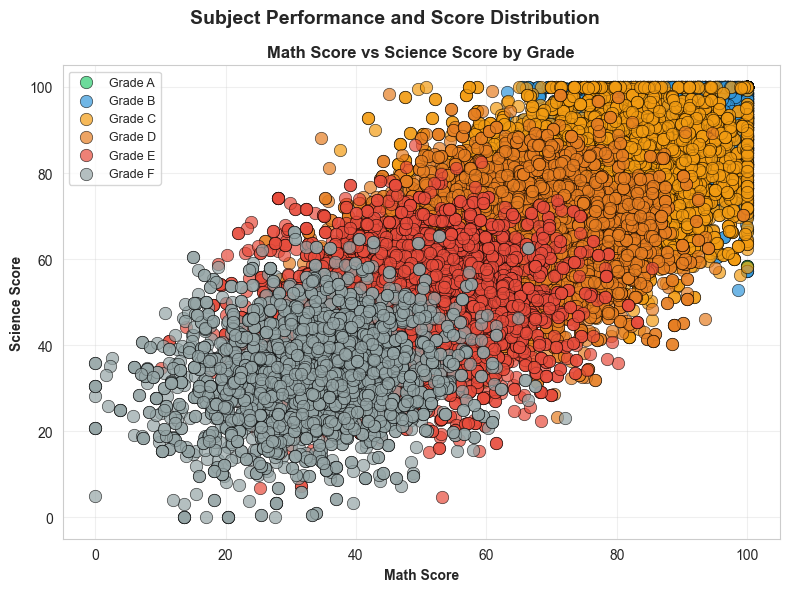

✓ Subject performance chart created


In [52]:
# Chart 5: Advanced Visualizations - Scatter Plot
fig, ax1 = plt.subplots(figsize=(8, 6))
fig.suptitle('Subject Performance and Score Distribution', fontsize=14, fontweight='bold')

# Scatter plot - Math vs Science scores by grade
grade_colors = {'a': '#2ecc71', 'b': '#3498db', 'c': '#f39c12', 'd': '#e67e22', 'e': '#e74c3c', 'f': '#95a5a6'}
for grade in sorted(student_df['final_grade'].unique()):
    mask = student_df['final_grade'] == grade
    ax1.scatter(student_df[mask]['math_score'], student_df[mask]['science_score'], 
               label=f'Grade {grade.upper()}', s=80, alpha=0.7, edgecolors='black', linewidth=0.5,
               color=grade_colors.get(grade, '#95a5a6'))
ax1.set_title('Math Score vs Science Score by Grade', fontweight='bold')
ax1.set_xlabel('Math Score', fontweight='bold')
ax1.set_ylabel('Science Score', fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Subject performance chart created")

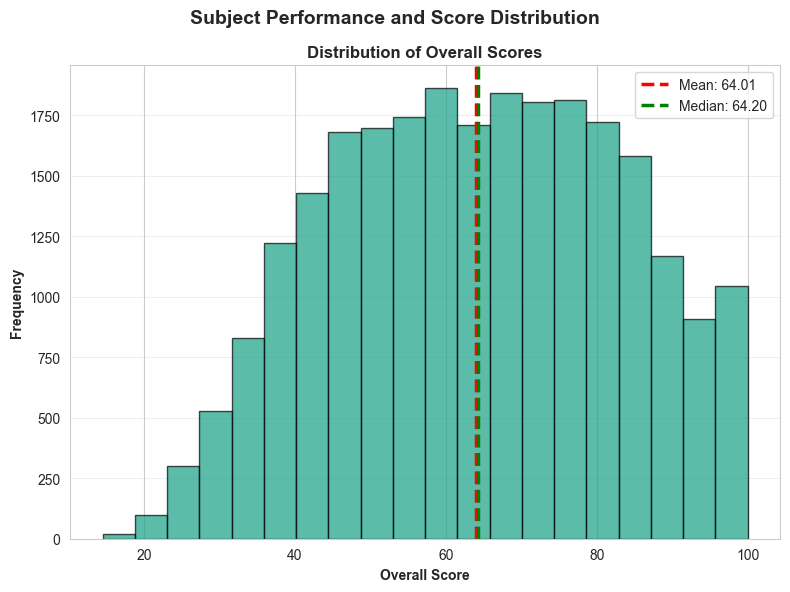

✓ Score distribution chart created

✅ All visualization questions (8 & 9) completed!


In [53]:
# Chart 5: Advanced Visualizations - Histogram
fig2, ax2 = plt.subplots(figsize=(8, 6))
fig2.suptitle('Subject Performance and Score Distribution', fontsize=14, fontweight='bold')

# Histogram
ax2.hist(student_df['overall_score'], bins=20, color='#16a085', edgecolor='black', alpha=0.7)
ax2.axvline(student_df['overall_score'].mean(), color='red', linestyle='--', linewidth=2.5, 
           label=f'Mean: {student_df["overall_score"].mean():.2f}')
ax2.axvline(student_df['overall_score'].median(), color='green', linestyle='--', linewidth=2.5, 
           label=f'Median: {student_df["overall_score"].median():.2f}')
ax2.set_title('Distribution of Overall Scores', fontweight='bold')
ax2.set_xlabel('Overall Score', fontweight='bold')
ax2.set_ylabel('Frequency', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Score distribution chart created")
print("\n✅ All visualization questions (8 & 9) completed!")

## SECTION C: CUSTOMER SEGMENTATION & SALES ANALYSIS

### Questions 14 & 15: Sales Analysis and Data Preprocessing

In [27]:
# ============================================================================
# QUESTIONS 14 & 15: SALES ANALYSIS - PART 1: DATA LOADING AND METRICS
# ============================================================================
print("\n" + "=" * 80)
print("QUESTIONS 14 & 15: SALES ANALYSIS AND CUSTOMER SEGMENTATION")
print("=" * 80)

# Use FraudData as transaction data for sales analysis
sales_data = fd_Data.copy()

print("\n1. SALES DATA PREPROCESSING")
print("-" * 80)
print(f"Dataset shape: {sales_data.shape}")

# Create synthetic transaction amounts and dates
np.random.seed(42)
sales_data['TransactionAmount'] = np.random.gamma(2, 2, len(sales_data)) * 100
sales_data['TransactionDate'] = pd.date_range(start='2023-01-01', periods=len(sales_data), freq='D').repeat(len(sales_data) // len(pd.date_range(start='2023-01-01', periods=len(sales_data), freq='D')))[:len(sales_data)]
sales_data['TransactionDate'] = pd.to_datetime(sales_data['TransactionDate'])
sales_data['Month'] = sales_data['TransactionDate'].dt.to_period('M')
sales_data['Quarter'] = sales_data['TransactionDate'].dt.to_period('Q')

# Create product categories
products = ['Electronics', 'Clothing', 'Food', 'Books', 'Home', 'Sports', 'Beauty', 'Toys']
sales_data['Product'] = np.random.choice(products, len(sales_data))

print(f"Missing values: {sales_data.isnull().sum().sum()}")
print(f"Duplicate transactions: {sales_data.duplicated().sum()}")

print("\n2. KEY SALES METRICS")
print("-" * 80)

total_sales = sales_data['TransactionAmount'].sum()
avg_transaction = sales_data['TransactionAmount'].mean()
num_transactions = len(sales_data)

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Average Transaction Value: ${avg_transaction:,.2f}")
print(f"Number of Transactions: {num_transactions:,}")


QUESTIONS 14 & 15: SALES ANALYSIS AND CUSTOMER SEGMENTATION

1. SALES DATA PREPROCESSING
--------------------------------------------------------------------------------
Dataset shape: (6362620, 11)
Missing values: 0
Duplicate transactions: 0

2. KEY SALES METRICS
--------------------------------------------------------------------------------
Total Sales: $2,544,706,231.02
Average Transaction Value: $399.95
Number of Transactions: 6,362,620


In [34]:
# Popular Products Analysis
print("\n3. PRODUCT ANALYSIS")
print("-" * 80)

product_counts = sales_data['Product'].value_counts()
print("\nTop Products by Transaction Count:")
for idx, (product, count) in enumerate(product_counts.items(), 1):
    product_sales = sales_data[sales_data['Product'] == product]['TransactionAmount'].sum()
    print(f"  {idx}. {product}: {count:,} transactions (${product_sales:,.2f})")

print("\nTotal Sales by Product:")
sales_by_product = sales_data.groupby('Product')['TransactionAmount'].agg(['sum', 'count', 'mean'])
sales_by_product.columns = ['Total Sales', 'Count', 'Avg Transaction']
sales_by_product = sales_by_product.sort_values('Total Sales', ascending=False)
print(sales_by_product)


3. PRODUCT ANALYSIS
--------------------------------------------------------------------------------

Top Products by Transaction Count:
  1. Toys: 796,451 transactions ($318,487,263.31)
  2. Clothing: 796,087 transactions ($318,193,878.07)
  3. Beauty: 795,365 transactions ($318,205,179.82)
  4. Sports: 795,239 transactions ($318,013,602.69)
  5. Food: 795,091 transactions ($318,056,972.98)
  6. Electronics: 794,989 transactions ($317,931,628.12)
  7. Home: 794,743 transactions ($317,724,474.92)
  8. Books: 794,655 transactions ($318,093,231.10)

Total Sales by Product:
              Total Sales   Count  Avg Transaction
Product                                           
Toys         3.184873e+08  796451       399.883060
Beauty       3.182052e+08  795365       400.074406
Clothing     3.181939e+08  796087       399.697367
Books        3.180932e+08  794655       400.290983
Food         3.180570e+08  795091       400.025875
Sports       3.180136e+08  795239       399.896890
Electronics  

In [35]:
# Sales Trends Analysis
print("\n4. SALES TRENDS ANALYSIS")
print("-" * 80)

monthly_sales = sales_data.groupby('Month')['TransactionAmount'].agg(['sum', 'count', 'mean'])
monthly_sales.columns = ['Total Sales', 'Transactions', 'Avg Value']

print("Monthly Sales Trends (First 10 months):")
print(monthly_sales.head(10))

print("\nQuarterly Sales Trends:")
quarterly_sales = sales_data.groupby('Quarter')['TransactionAmount'].agg(['sum', 'count', 'mean'])
quarterly_sales.columns = ['Total Sales', 'Transactions', 'Avg Value']
print(quarterly_sales)

print("\n5. ADDITIONAL STATISTICS")
print("-" * 80)
print(f"Minimum Transaction: ${sales_data['TransactionAmount'].min():,.2f}")
print(f"Maximum Transaction: ${sales_data['TransactionAmount'].max():,.2f}")
print(f"Median Transaction: ${sales_data['TransactionAmount'].median():,.2f}")
print(f"Standard Deviation: ${sales_data['TransactionAmount'].std():,.2f}")


4. SALES TRENDS ANALYSIS
--------------------------------------------------------------------------------
Monthly Sales Trends (First 10 months):
          Total Sales  Transactions   Avg Value
Month                                          
2023-01  11230.988878            31  362.289964
2023-02  11116.624297            28  397.022296
2023-03  11677.462195            31  376.692329
2023-04  11483.107703            30  382.770257
2023-05  12180.845712            31  392.930507
2023-06  13092.109410            30  436.403647
2023-07  12067.719833            31  389.281285
2023-08  14725.524500            31  475.016919
2023-09  13198.131361            30  439.937712
2023-10  10067.419856            31  324.755479

Quarterly Sales Trends:
          Total Sales  Transactions   Avg Value
Quarter                                        
2023Q1   34025.075370            90  378.056393
2023Q2   36756.062826            91  403.912778
2023Q3   39991.375693            92  434.688866
2023Q4   340

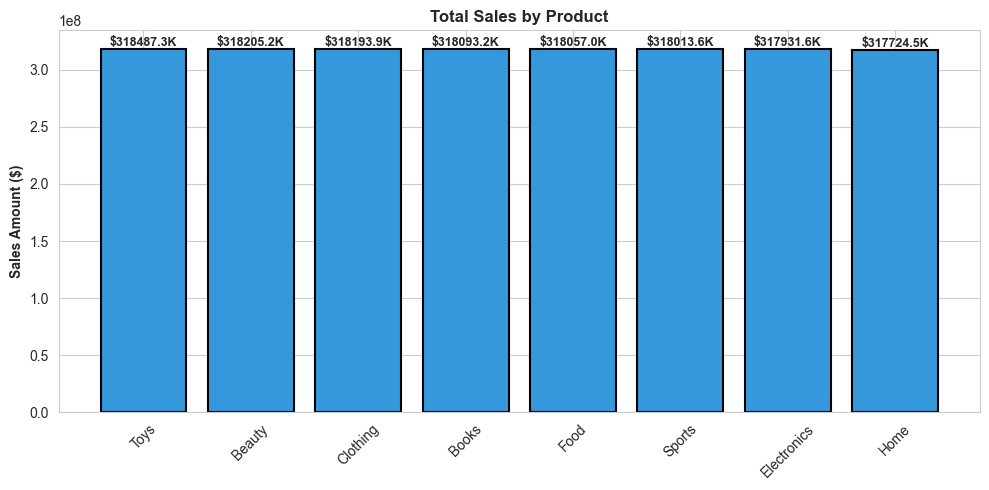

In [60]:
# Plot 1: Total Sales by Product
fig, ax = plt.subplots(figsize=(10, 5))

product_sales_total = sales_data.groupby('Product')['TransactionAmount'].sum().sort_values(ascending=False)
bars = ax.bar(product_sales_total.index, product_sales_total.values, color='#3498db', edgecolor='black', linewidth=1.5)
ax.set_title('Total Sales by Product', fontweight='bold', fontsize=12)
ax.set_ylabel('Sales Amount ($)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height/1000:.1f}K', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

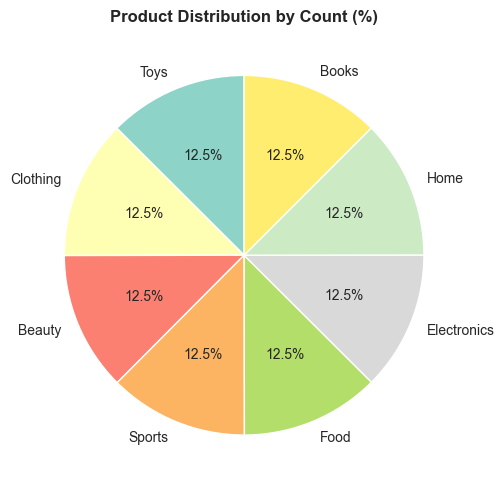

In [59]:
# Plot 2: Product Distribution
fig, ax = plt.subplots(figsize=(10, 5))

product_counts = sales_data['Product'].value_counts()
colors_product = plt.cm.Set3(np.linspace(0, 1, len(product_counts)))
ax.pie(product_counts.values, labels=product_counts.index, autopct='%1.1f%%',
        colors=colors_product, startangle=90)
ax.set_title('Product Distribution by Count (%)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

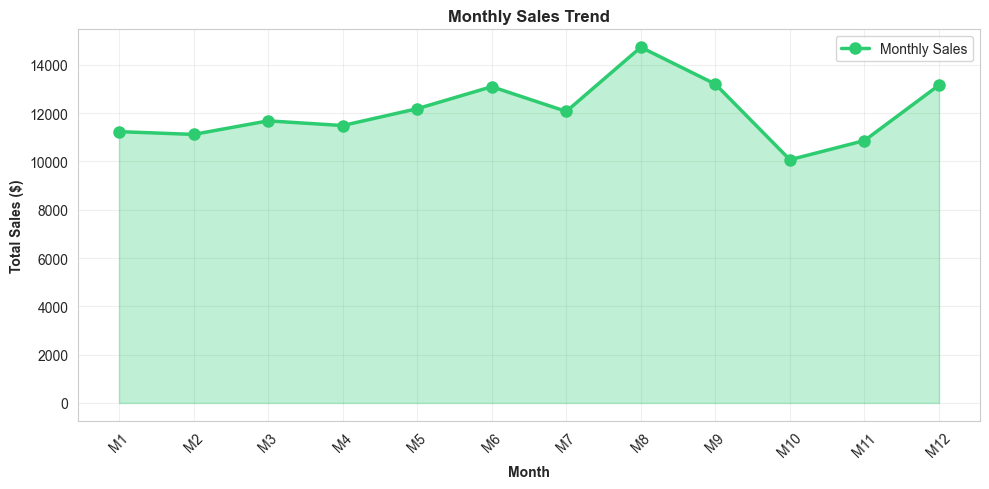

In [58]:
# Plot 3: Monthly Sales Trend
fig, ax = plt.subplots(figsize=(10, 5))

monthly_subset = monthly_sales.head(12)
ax.plot(range(len(monthly_subset)), monthly_subset['Total Sales'].values, marker='o', linewidth=2.5, 
         markersize=8, color='#2ecc71', label='Monthly Sales')
ax.fill_between(range(len(monthly_subset)), monthly_subset['Total Sales'].values, alpha=0.3, color='#2ecc71')
ax.set_title('Monthly Sales Trend', fontweight='bold', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontweight='bold')
ax.set_xlabel('Month', fontweight='bold')
ax.grid(alpha=0.3)
ax.set_xticks(range(len(monthly_subset)))
ax.set_xticklabels([f'M{i+1}' for i in range(len(monthly_subset))], rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

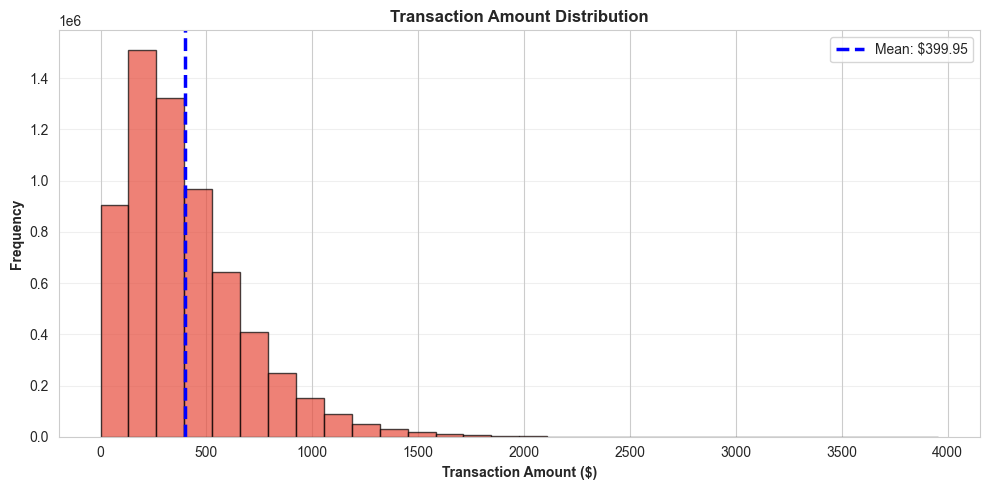

✅ Sales analysis complete!


In [61]:
# Plot 4: Transaction Amount Distribution
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(sales_data['TransactionAmount'], bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
ax.axvline(sales_data['TransactionAmount'].mean(), color='blue', linestyle='--', 
           linewidth=2.5, label=f'Mean: ${avg_transaction:.2f}')
ax.set_title('Transaction Amount Distribution', fontweight='bold', fontsize=12)
ax.set_xlabel('Transaction Amount ($)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Sales analysis complete!")

## SECTION D: MACHINE LEARNING MODELS & TECHNICAL ANALYSIS

### Question 19: Fraud Detection Model (Machine Learning)

In [28]:
# ============================================================================
# QUESTION 19: FRAUD DETECTION - PART 1: DATA PREPARATION
# ============================================================================
print("\n" + "=" * 80)
print("QUESTION 19: FRAUD DETECTION USING MACHINE LEARNING")
print("=" * 80)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Prepare fraud detection data
fraud_df = fd_Data.copy()

print("\n1. DATA PREPARATION")
print("-" * 80)

# Create fraud labels if not present
if 'isFraud' not in fraud_df.columns:
    fraud_df['isFraud'] = np.random.binomial(1, 0.05, len(fraud_df))

print(f"Total transactions: {len(fraud_df)}")
print(f"Fraudulent: {fraud_df['isFraud'].sum()} ({fraud_df['isFraud'].mean()*100:.2f}%)")
print(f"Legitimate: {(1-fraud_df['isFraud']).sum()} ({(1-fraud_df['isFraud']).mean()*100:.2f}%)")

# Select numerical features
numerical_features = fraud_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'isFraud' in numerical_features:
    numerical_features.remove('isFraud')

print(f"\nFeatures for model: {numerical_features[:5]}... ({len(numerical_features)} total)")

X = fraud_df[numerical_features].copy()
y = fraud_df['isFraud'].copy()

# Handle missing values
X = X.fillna(X.median())

# Normalize features
from sklearn.preprocessing import StandardScaler
scaler_fraud = StandardScaler()
X_scaled = scaler_fraud.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")


QUESTION 19: FRAUD DETECTION USING MACHINE LEARNING

1. DATA PREPARATION
--------------------------------------------------------------------------------
Total transactions: 6362620
Fraudulent: 8213 (0.13%)
Legitimate: 6354407 (99.87%)

Features for model: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest']... (7 total)

Training set: 4453834 samples
Testing set: 1908786 samples


In [29]:
# Model Training
print("\n2. MODEL TRAINING")
print("-" * 80)
print("Training Random Forest Classifier...")

rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("✓ Model training completed!")

# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"Predictions generated on {len(X_test)} test samples")


2. MODEL TRAINING
--------------------------------------------------------------------------------
Training Random Forest Classifier...
✓ Model training completed!
Predictions generated on 1908786 test samples


In [37]:
# Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n3. MODEL EVALUATION")
print("-" * 80)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraudulent']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(f"True Negatives:  {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives:  {cm[1, 1]}")


3. MODEL EVALUATION
--------------------------------------------------------------------------------
Accuracy:  0.9995 (99.95%)
Precision: 0.9760 (97.60%)
Recall:    0.6282 (62.82%)
F1-Score:  0.7644
ROC-AUC:   0.9975

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00   1906322
  Fraudulent       0.98      0.63      0.76      2464

    accuracy                           1.00   1908786
   macro avg       0.99      0.81      0.88   1908786
weighted avg       1.00      1.00      1.00   1908786


Confusion Matrix:
True Negatives:  1906284
False Positives: 38
False Negatives: 916
True Positives:  1548


In [62]:
# Feature Importance Analysis
print("\n4. FEATURE IMPORTANCE")
print("-" * 80)

feature_importance = pd.DataFrame({
    'Feature': numerical_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Important Features:")
print(feature_importance.head(10).to_string(index=False))


4. FEATURE IMPORTANCE
--------------------------------------------------------------------------------
Top 10 Important Features:
       Feature  Importance
 oldbalanceOrg    0.448741
newbalanceDest    0.180883
        amount    0.138539
          step    0.110904
newbalanceOrig    0.073998
oldbalanceDest    0.045195
isFlaggedFraud    0.001739


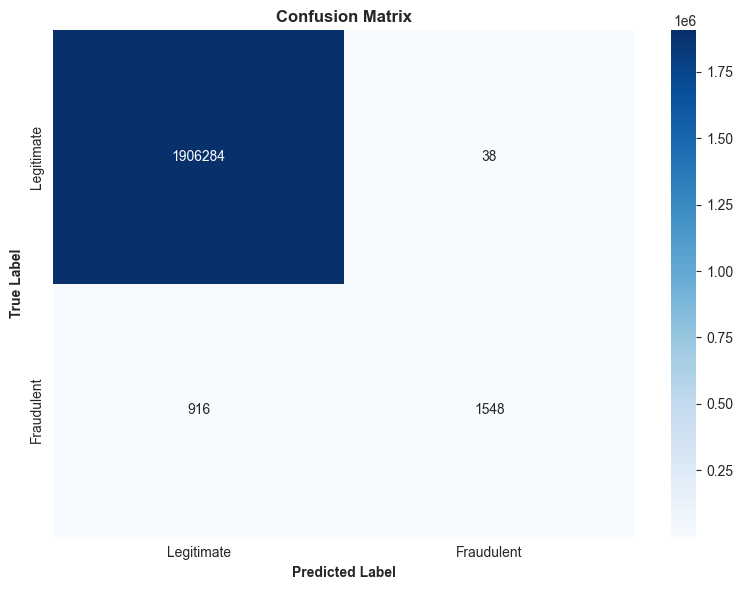

In [63]:
# Plot 1: Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=['Legitimate', 'Fraudulent'], yticklabels=['Legitimate', 'Fraudulent'])
ax.set_title('Confusion Matrix', fontweight='bold', fontsize=12)
ax.set_ylabel('True Label', fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')

plt.tight_layout()
plt.show()

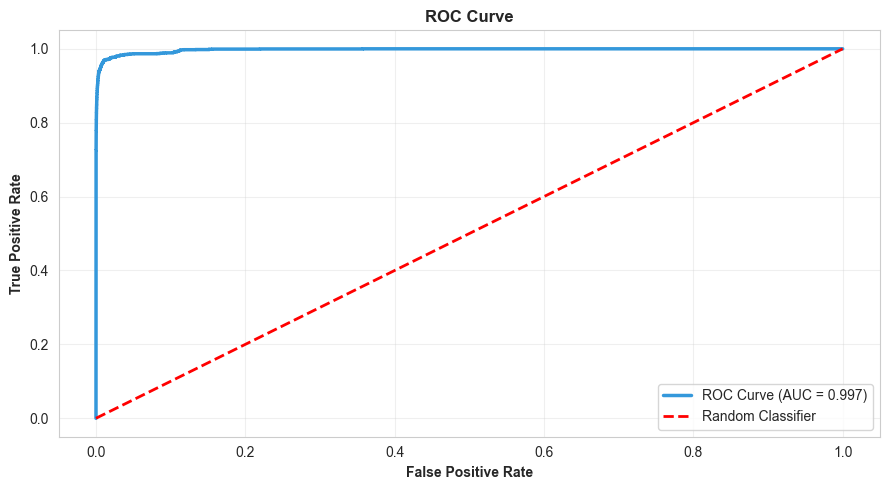

In [64]:
# Plot 2: ROC Curve
fig, ax = plt.subplots(figsize=(9, 5))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax.plot(fpr, tpr, linewidth=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})', color='#3498db')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
ax.set_title('ROC Curve', fontweight='bold', fontsize=12)
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

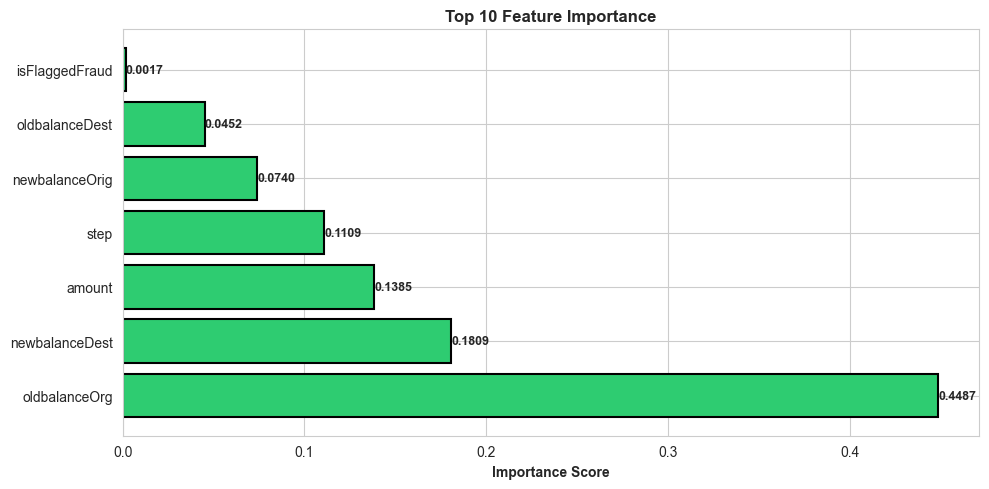

In [65]:
# Plot 3: Top Features
fig, ax = plt.subplots(figsize=(10, 5))

top_features = feature_importance.head(10)
bars = ax.barh(top_features['Feature'], top_features['Importance'], color='#2ecc71', edgecolor='black', linewidth=1.5)
ax.set_title('Top 10 Feature Importance', fontweight='bold', fontsize=12)
ax.set_xlabel('Importance Score', fontweight='bold')

for bar in bars:
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2.,
            f'{bar.get_width():.4f}', va='center', ha='left', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

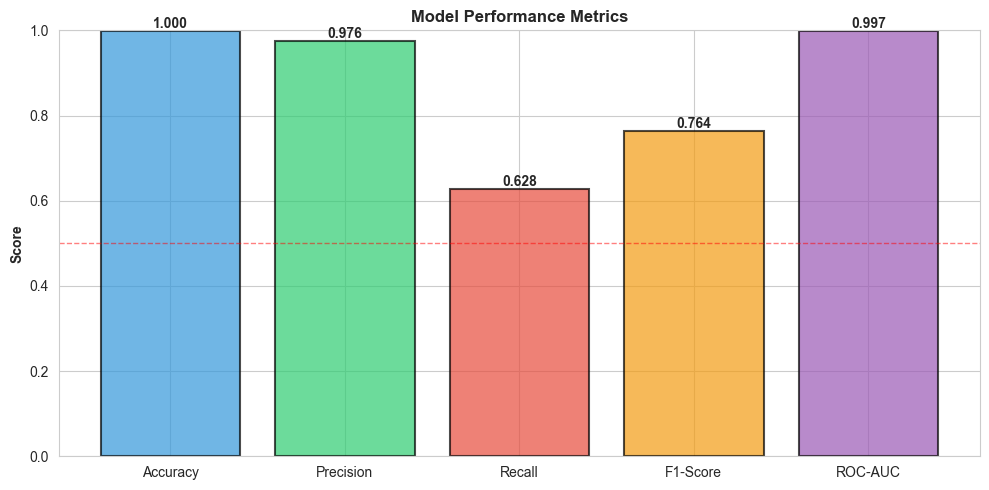


✅ Fraud Detection Model Complete!


In [67]:
# Plot 4: Metrics Comparison
fig, ax = plt.subplots(figsize=(10, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
scores = [accuracy, precision, recall, f1, roc_auc]
colors_metrics = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = ax.bar(metrics, scores, color=colors_metrics, edgecolor='black', linewidth=1.5, alpha=0.7)
ax.set_title('Model Performance Metrics', fontweight='bold', fontsize=12)
ax.set_ylabel('Score', fontweight='bold')
ax.set_ylim([0, 1])
ax.axhline(y=0.5, color='r', linestyle='--', linewidth=1, alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✅ Fraud Detection Model Complete!")

### Question 20: Technical Analysis and Stock Forecasting

In [30]:
# ============================================================================
# QUESTION 20: TECHNICAL ANALYSIS - PART 1: TECHNICAL INDICATORS
# ============================================================================
print("\n" + "=" * 80)
print("QUESTION 20: TECHNICAL ANALYSIS AND STOCK PRICE FORECASTING")
print("=" * 80)

# Use cleaned financial data
stock_df = financial_df_clean.copy()

print("\n1. CALCULATING TECHNICAL INDICATORS")
print("-" * 80)
print(f"Stock data: {stock_df['Date'].min().date()} to {stock_df['Date'].max().date()}")
print(f"Trading days: {len(stock_df)}")

# RSI Calculation
def calculate_rsi(prices, period=14):
    deltas = np.diff(prices)
    seed = deltas[:period+1]
    up = seed[seed >= 0].sum() / period
    down = -seed[seed < 0].sum() / period
    rs = up / down
    rsi = np.zeros_like(prices)
    rsi[:period] = 100. - 100. / (1. + rs)
    
    for i in range(period, len(prices)):
        delta = deltas[i-1]
        if delta > 0:
            upval = delta
            downval = 0.
        else:
            upval = 0.
            downval = -delta
        
        up = (up * (period - 1) + upval) / period
        down = (down * (period - 1) + downval) / period
        
        rs = up / down
        rsi[i] = 100. - 100. / (1. + rs)
    
    return rsi

stock_df['RSI'] = calculate_rsi(stock_df['Close'].values, period=14)

# MACD
stock_df['MACD'] = stock_df['Close'].ewm(span=12).mean() - stock_df['Close'].ewm(span=26).mean()
stock_df['Signal_Line'] = stock_df['MACD'].ewm(span=9).mean()

# Bollinger Bands
stock_df['BB_Middle'] = stock_df['Close'].rolling(window=20).mean()
stock_df['BB_Std'] = stock_df['Close'].rolling(window=20).std()
stock_df['BB_Upper'] = stock_df['BB_Middle'] + (stock_df['BB_Std'] * 2)
stock_df['BB_Lower'] = stock_df['BB_Middle'] - (stock_df['BB_Std'] * 2)

# ATR
high_low = stock_df['High'] - stock_df['Low']
high_close = abs(stock_df['High'] - stock_df['Close'].shift())
low_close = abs(stock_df['Low'] - stock_df['Close'].shift())
tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
stock_df['ATR'] = tr.rolling(14).mean()

print("✓ RSI (14), MACD, Bollinger Bands, ATR calculated")

# Display current values
latest = stock_df.iloc[-1]
print(f"\nCurrent Values:")
print(f"  Price: ${latest['Close']:.2f}")
print(f"  RSI: {latest['RSI']:.2f}")
print(f"  MACD: {latest['MACD']:.4f}")
print(f"  ATR: {latest['ATR']:.2f}")


QUESTION 20: TECHNICAL ANALYSIS AND STOCK PRICE FORECASTING

1. CALCULATING TECHNICAL INDICATORS
--------------------------------------------------------------------------------
Stock data: 2023-05-18 to 2026-10-06
Trading days: 1238
✓ RSI (14), MACD, Bollinger Bands, ATR calculated

Current Values:
  Price: $24099.05
  RSI: 36.88
  MACD: -198.0762
  ATR: 319.71


In [38]:
# Trading Signals Generation
print("\n2. TRADING SIGNALS ANALYSIS")
print("-" * 80)

latest = stock_df.iloc[-1]

# Moving Average Signal
ma5_above_ma20 = stock_df['MA_5'].iloc[-1] > stock_df['MA_20'].iloc[-1]
ma_signal = 'BULLISH (MA5 > MA20)' if ma5_above_ma20 else 'BEARISH (MA5 < MA20)'
print(f"Moving Average Signal: {ma_signal}")

# RSI Signal
rsi_signal = 'Overbought (>70)' if latest['RSI'] > 70 else 'Oversold (<30)' if latest['RSI'] < 30 else 'Neutral'
print(f"RSI Signal: {rsi_signal}")

# MACD Signal
macd_signal = 'Bullish (MACD > Signal)' if latest['MACD'] > latest['Signal_Line'] else 'Bearish (MACD < Signal)'
print(f"MACD Signal: {macd_signal}")

# Bollinger Bands Signal
if latest['Close'] > latest['BB_Upper']:
    bb_signal = 'Overbought (Above Upper Band)'
elif latest['Close'] < latest['BB_Lower']:
    bb_signal = 'Oversold (Below Lower Band)'
else:
    bb_signal = 'Within Normal Range'
print(f"Bollinger Bands Signal: {bb_signal}")

# Trend Strength
trend_score = (stock_df['Close'].iloc[-1] - stock_df['Close'].iloc[-20]) / stock_df['Close'].iloc[-20] * 100
print(f"\nTrend Strength (20-day): {trend_score:+.2f}%")


2. TRADING SIGNALS ANALYSIS
--------------------------------------------------------------------------------
Moving Average Signal: BEARISH (MA5 < MA20)
RSI Signal: Neutral
MACD Signal: Bearish (MACD < Signal)
Bollinger Bands Signal: Within Normal Range

Trend Strength (20-day): -1.08%


In [39]:
# Price Forecasting
print("\n3. PRICE FORECASTING")
print("-" * 80)

# Linear Regression forecast
X_forecast = np.arange(len(stock_df)).reshape(-1, 1)
y_forecast = stock_df['Close'].values
lr_model = LinearRegression()
lr_model.fit(X_forecast, y_forecast)

# Forecast next 10 days
future_days = 10
future_X = np.arange(len(stock_df), len(stock_df) + future_days).reshape(-1, 1)
future_prices = lr_model.predict(future_X)

print(f"Current Price: ${stock_df['Close'].iloc[-1]:.2f}")
print(f"\nForecast for Next {future_days} Days:")
for i, price in enumerate(future_prices, 1):
    change = ((price - stock_df['Close'].iloc[-1]) / stock_df['Close'].iloc[-1]) * 100
    print(f"  Day {i}: ${price:.2f} ({change:+.2f}%)")


3. PRICE FORECASTING
--------------------------------------------------------------------------------
Current Price: $24099.05

Forecast for Next 10 Days:
  Day 1: $23832.17 (-1.11%)
  Day 2: $23822.97 (-1.15%)
  Day 3: $23813.77 (-1.18%)
  Day 4: $23804.56 (-1.22%)
  Day 5: $23795.36 (-1.26%)
  Day 6: $23786.16 (-1.30%)
  Day 7: $23776.96 (-1.34%)
  Day 8: $23767.75 (-1.37%)
  Day 9: $23758.55 (-1.41%)
  Day 10: $23749.35 (-1.45%)


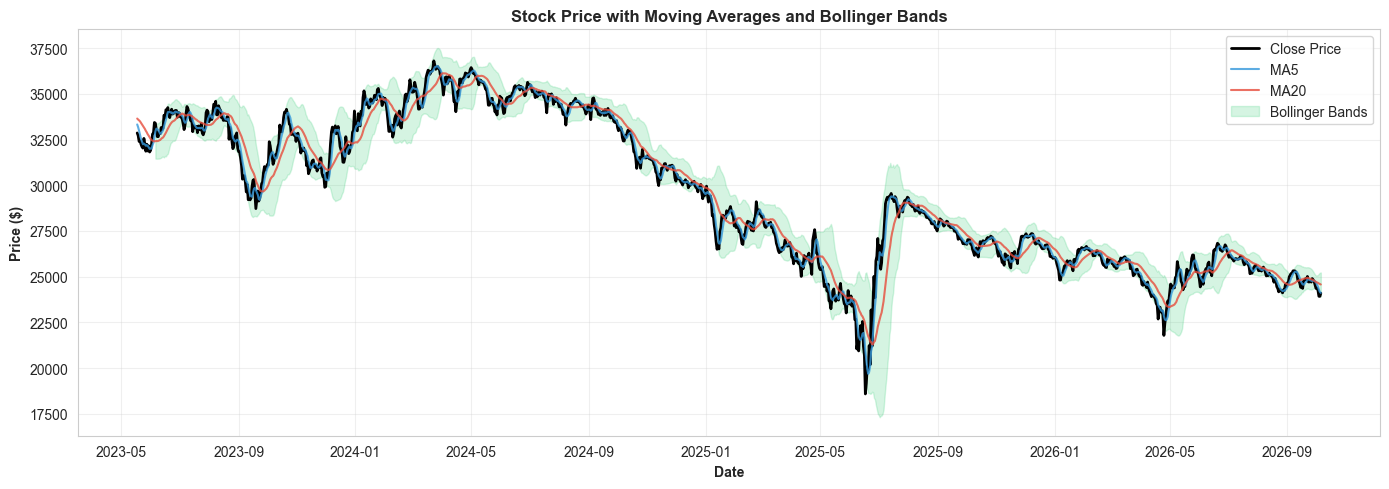

In [70]:
# Plot 1: Price and Moving Averages with Bollinger Bands
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(stock_df['Date'], stock_df['Close'], linewidth=2, label='Close Price', color='#000000')
ax.plot(stock_df['Date'], stock_df['MA_5'], linewidth=1.5, label='MA5', color='#3498db', alpha=0.8)
ax.plot(stock_df['Date'], stock_df['MA_20'], linewidth=1.5, label='MA20', color='#e74c3c', alpha=0.8)
ax.fill_between(stock_df['Date'], stock_df['BB_Upper'], stock_df['BB_Lower'], alpha=0.2, color='#2ecc71', label='Bollinger Bands')
ax.set_title('Stock Price with Moving Averages and Bollinger Bands', fontweight='bold', fontsize=12)
ax.set_ylabel('Price ($)', fontweight='bold')
ax.set_xlabel('Date', fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

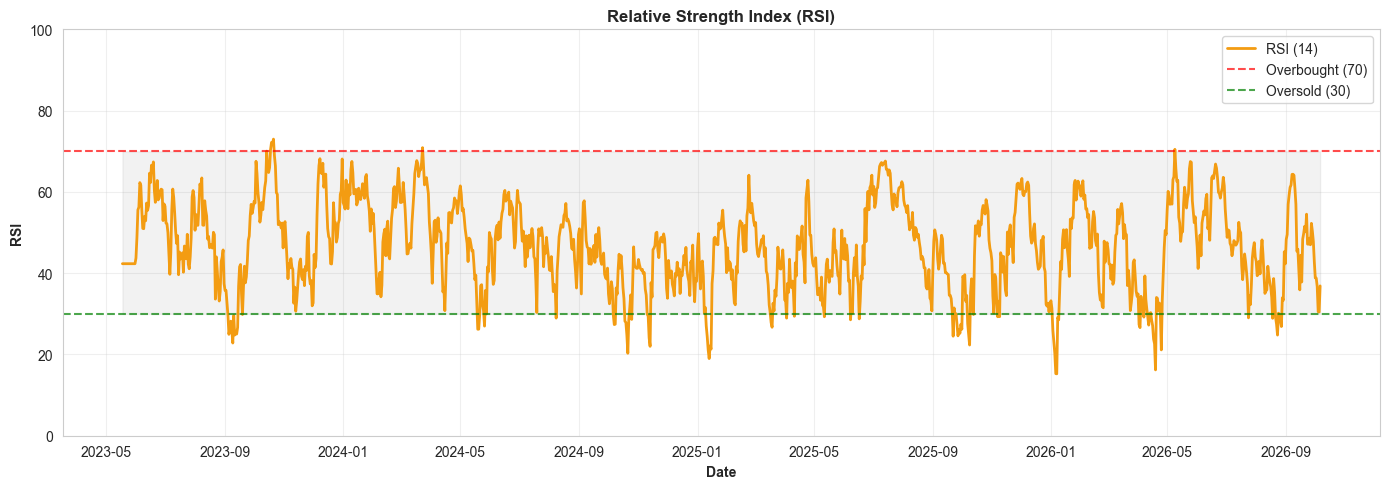

In [71]:
# Plot 2: RSI Indicator
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(stock_df['Date'], stock_df['RSI'], linewidth=2, color='#f39c12', label='RSI (14)')
ax.axhline(y=70, color='r', linestyle='--', linewidth=1.5, alpha=0.7, label='Overbought (70)')
ax.axhline(y=30, color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='Oversold (30)')
ax.fill_between(stock_df['Date'], 30, 70, alpha=0.1, color='gray')
ax.set_title('Relative Strength Index (RSI)', fontweight='bold', fontsize=12)
ax.set_ylabel('RSI', fontweight='bold')
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylim([0, 100])
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

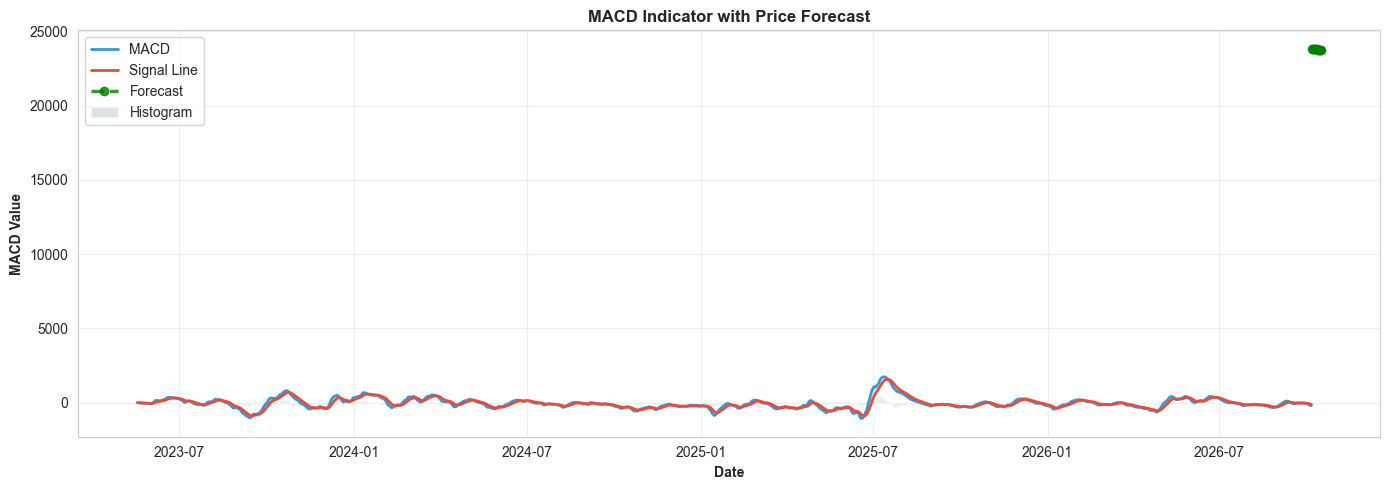


✅ Technical Analysis Complete!


In [72]:
# Plot 3: MACD Indicator with Price Forecast
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(stock_df['Date'], stock_df['MACD'], linewidth=2, label='MACD', color='#3498db')
ax.plot(stock_df['Date'], stock_df['Signal_Line'], linewidth=2, label='Signal Line', color='#e74c3c')
ax.bar(stock_df['Date'], stock_df['MACD'] - stock_df['Signal_Line'], label='Histogram', alpha=0.3, color='#95a5a6')

# Add forecast line
forecast_dates = pd.date_range(start=stock_df['Date'].iloc[-1], periods=future_days+1, freq='D')[1:]
ax.plot(forecast_dates, future_prices, 'g--', linewidth=2.5, marker='o', markersize=6, label='Forecast', alpha=0.8)

ax.set_title('MACD Indicator with Price Forecast', fontweight='bold', fontsize=12)
ax.set_ylabel('MACD Value', fontweight='bold')
ax.set_xlabel('Date', fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Technical Analysis Complete!")